In [76]:
import pandas as pd
import seaborn as sns
import numpy as np
from apyori import apriori

In [77]:
df=pd.DataFrame(pd.read_csv('Market_Basket - Market_Basket.csv',header=None))

In [78]:
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,butter,light mayo,fresh bread,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7497,burgers,frozen vegetables,eggs,french fries,magazines,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7498,chicken,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7499,escalope,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
df.shape

(7501, 20)

In [80]:
df_list=(df.to_numpy())
df_list

array([['shrimp', 'almonds', 'avocado', ..., 'frozen smoothie',
        'spinach', 'olive oil'],
       ['burgers', 'meatballs', 'eggs', ..., nan, nan, nan],
       ['chutney', nan, nan, ..., nan, nan, nan],
       ...,
       ['chicken', nan, nan, ..., nan, nan, nan],
       ['escalope', 'green tea', nan, ..., nan, nan, nan],
       ['eggs', 'frozen smoothie', 'yogurt cake', ..., nan, nan, nan]],
      dtype=object)

In [81]:
#Use Series
x=pd.Series(df_list.flatten())
x.dropna(inplace=True)


C:\Users\ARJUN\AppData\Local\Temp\ipykernel_66352\1267659924.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x.value_counts().head(20).index,y=x.value_counts().head(20),palette=['red','green','blue'])
C:\Users\ARJUN\AppData\Local\Temp\ipykernel_66352\1267659924.py:1: UserWarning: 
The palette list has fewer values (3) than needed (20) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=x.value_counts().head(20).index,y=x.value_counts().head(20),palette=['red','green','blue'])


<Axes: xlabel='None', ylabel='count'>

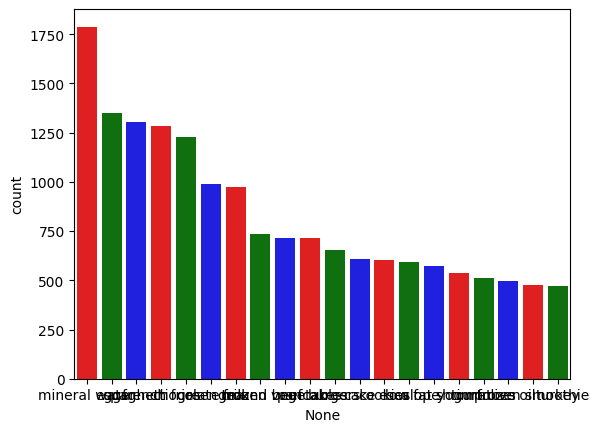

In [82]:
sns.barplot(x=x.value_counts().head(20).index,y=x.value_counts().head(20),palette=['red','green','blue'])

In [83]:
df_list=df_list.tolist()
for ele in df_list:
    while np.nan in ele:
        ele.remove(np.nan)
df_list       

[['shrimp',
  'almonds',
  'avocado',
  'vegetables mix',
  'green grapes',
  'whole weat flour',
  'yams',
  'cottage cheese',
  'energy drink',
  'tomato juice',
  'low fat yogurt',
  'green tea',
  'honey',
  'salad',
  'mineral water',
  'salmon',
  'antioxydant juice',
  'frozen smoothie',
  'spinach',
  'olive oil'],
 ['burgers', 'meatballs', 'eggs'],
 ['chutney'],
 ['turkey', 'avocado'],
 ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea'],
 ['low fat yogurt'],
 ['whole wheat pasta', 'french fries'],
 ['soup', 'light cream', 'shallot'],
 ['frozen vegetables', 'spaghetti', 'green tea'],
 ['french fries'],
 ['eggs', 'pet food'],
 ['cookies'],
 ['turkey', 'burgers', 'mineral water', 'eggs', 'cooking oil'],
 ['spaghetti', 'champagne', 'cookies'],
 ['mineral water', 'salmon'],
 ['mineral water'],
 ['shrimp',
  'chocolate',
  'chicken',
  'honey',
  'oil',
  'cooking oil',
  'low fat yogurt'],
 ['turkey', 'eggs'],
 ['turkey',
  'fresh tuna',
  'tomatoes',
  'spagh

In [84]:
rules1=apriori(df_list,min_support=0.05,min_confidence=0.05)
r1=list(rules1)

In [85]:
frequent_items = []
supports = []
confidences = []
lifts = []

In [86]:
for r in r1:
    if not hasattr(r, "ordered_statistics") or len(r.ordered_statistics) == 0:
        continue
    for x in r.ordered_statistics:
        if len(x.items_base) > 0 and len(x.items_add) > 0:
            frequent_items.append(tuple(x.items_base) + tuple(x.items_add))
            supports.append(r.support)
            confidences.append(x.confidence)
            lifts.append(x.lift)


In [87]:
min_len = min(len(frequent_items), len(supports), len(confidences), len(lifts))
frequent_items = frequent_items[:min_len]
supports = supports[:min_len]
confidences = confidences[:min_len]
lifts = lifts[:min_len]

In [88]:
rules1_df = pd.DataFrame({
    'Frequent Itemset': frequent_items,
    'Support': supports,
    'Confidence': confidences,
    'Lift': lifts
}).sort_values(by='Lift', ascending=False).reset_index(drop=True)
rules1_df

,Frequent Itemset,Support,Confidence,Lift
0,"(mineral water, spaghetti)",0.059725,0.250559,1.439085
1,"(spaghetti, mineral water)",0.059725,0.343032,1.439085
2,"(chocolate, mineral water)",0.052660,0.321400,1.348332
3,"(mineral water, chocolate)",0.052660,0.220917,1.348332
4,"(mineral water, eggs)",0.050927,0.213647,1.188845
5,"(eggs, mineral water)",0.050927,0.283383,1.188845


In [89]:
rules2=apriori(df_list,min_support=0.01,min_confidence=0.01)
r2=list(rules2)

In [90]:
frequent_items = []
supports = []
confidences = []
lifts = []

In [91]:
for r in r2:
    if not hasattr(r, "ordered_statistics") or len(r.ordered_statistics) == 0:
        continue
    for x in r.ordered_statistics:
        if len(x.items_base) > 0 and len(x.items_add) > 0:
            frequent_items.append(tuple(x.items_base) + tuple(x.items_add))
            supports.append(r.support)
            confidences.append(x.confidence)
            lifts.append(x.lift)

In [92]:
min_len = min(len(frequent_items), len(supports), len(confidences), len(lifts))
frequent_items = frequent_items[:min_len]
supports = supports[:min_len]
confidences = confidences[:min_len]
lifts = lifts[:min_len]

In [94]:
rules2_df = pd.DataFrame({
    'Frequent Itemset': frequent_items,
    'Support': supports,
    'Confidence': confidences,
    'Lift': lifts
}).sort_values(by='Lift', ascending=False).reset_index(drop=True)
rules2_df.head()

,Frequent Itemset,Support,Confidence,Lift
0,"(herb & pepper, ground beef)",0.015998,0.323450,3.291994
1,"(ground beef, herb & pepper)",0.015998,0.162822,3.291994
2,"(spaghetti, mineral water, ground beef)",0.017064,0.285714,2.907928
3,"(ground beef, spaghetti, mineral water)",0.017064,0.173677,2.907928
4,"(olive oil, spaghetti, mineral water)",0.010265,0.155870,2.609786
